
# Fitting NuSTAR Spectra: Glesener *et al.* 2020 comparison

A real example from [Glesener2020]_ of fitting two NuSTAR spectra simultaneously with gain correction.


In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
from numpy.exceptions import VisibleDeprecationWarning
from parfive import Downloader

from sunkit_spex.legacy.fitting.fitter import Fitter

warnings.filterwarnings("ignore", category=RuntimeWarning)
try:
    warnings.filterwarnings("ignore", category=VisibleDeprecationWarning)
except AttributeError:
    warnings.filterwarnings("ignore", category=np.exceptions.VisibleDeprecationWarning)

Set up some plotting numbers



In [2]:
spec_single_plot_size = (8, 10)
spec_plot_size = (25, 10)
spec_font_size = 18
default_font_size = 10
x_limits, y_limits = [1.6, 8.5], [1e-1, 1e3]

# Let's fit a more realistic example

Try fitting the spectra presented in [Glesener *et al.* 2020](https://iopscience.iop.org/article/10.3847/2041-8213/ab7341). The spectrum presented shows clear evidence of non-thermal emission in an A5.7 microflare.

## Let's recreate Figure 4 (left) where NuSTAR FPMB is fitted with a thermal+cold thick target model.

set up plotting info stuff



In [3]:
gles_xlims, gles_ylims = [2, 12], [1e1, 1e4]

Download data files



In [4]:
# dl = Downloader()

# base_url = "https://homepages.dias.ie/smaloney/sunkit-spex/nustar/Glesener2020/"
# file_names = [
#     "nu20312001001B06_cl_grade0_sr_grp.pha",
#     "nu20312001001B06_cl_grade0_sr.arf",
#     "nu20312001001B06_cl_grade0_sr.rmf",
#     "nu20312001001A06_cl_grade0_sr_grp.pha",
#     "nu20312001001A06_cl_grade0_sr.arf",
#     "nu20312001001A06_cl_grade0_sr.rmf",
# ]

# for fname in file_names:
#     dl.enqueue_file(base_url + fname, path="data/")
# files = dl.download()

First, load in your data files, here we load in 2 spectra



In [5]:
_dir = "data/"
# In the files here, the ARF and RMF file have different names to the PHA files so cannot use the PHA file name to help find the others so...
spec = Fitter(
    pha_file=_dir + "nu20312001001B06_cl_grade0_sr_grp.pha",
    arf_file=_dir + "nu20312001001B06_cl_grade0_sr.arf",
    rmf_file=_dir + "nu20312001001B06_cl_grade0_sr.rmf",
)

Define model, here we go for a single isothermal model + cold thick model



In [6]:
spec.model = "f_vth + thick_fn"

Define fitting range



In [7]:
spec.energy_fitting_range = [2.8, 10.5]

Sort temperature param from f_vth



In [8]:
spec.params["T1_spectrum1"] = {"Value": 10.3, "Bounds": (1.1, 15)}
# emission measure param from f_vth
spec.params["EM1_spectrum1"] = {"Value": 0.5, "Bounds": (1e-2, 1e1)}
# electron flux param from thick_fn
spec.params["total_eflux1_spectrum1"] = {"Value": 2.1, "Bounds": (1e-3, 10)}  # units 1e35 e^-/s
# electron index param from thick_fn
spec.params["index1_spectrum1"] = {"Value": 6.2, "Bounds": (3, 10)}
# electron low energy cut-off param from thick_fn
spec.params["e_c1_spectrum1"] = {"Value": 6.2, "Bounds": (1, 12)}  # units keV

**This fit requires altering the gain parameters**

Gain parameters can be tweaked in the same way model parameters can.

The difference is that gain parameters all have specific starting values (slope=1, offset=0) and are frozen by default.



In [9]:
# from Glesener et al. 2020 which had a gain correction fixed at 0.95
spec.rParams["gain_slope_spectrum1"] = {"Status": "fixed", "Value": 0.95}

print(spec.rParams)

print(spec.show_rParams)

                       Status  Value       Bounds       Error
gain_slope_spectrum1   frozen   0.95   (0.8, 1.2)  (0.0, 0.0)
gain_offset_spectrum1  frozen   0.00  (-0.1, 0.1)  (0.0, 0.0)
        Param         Status   Value       Bounds            Error          
                                         (min, max)          (-, +)         
--------------------- ------ ---------- ----------- ------------------------
 gain_slope_spectrum1 frozen      0.950  (0.8, 1.2) (      0.00,       0.00)
gain_offset_spectrum1 frozen      0.000 (-0.1, 0.1) (      0.00,       0.00)


Fit the model to the spectrum



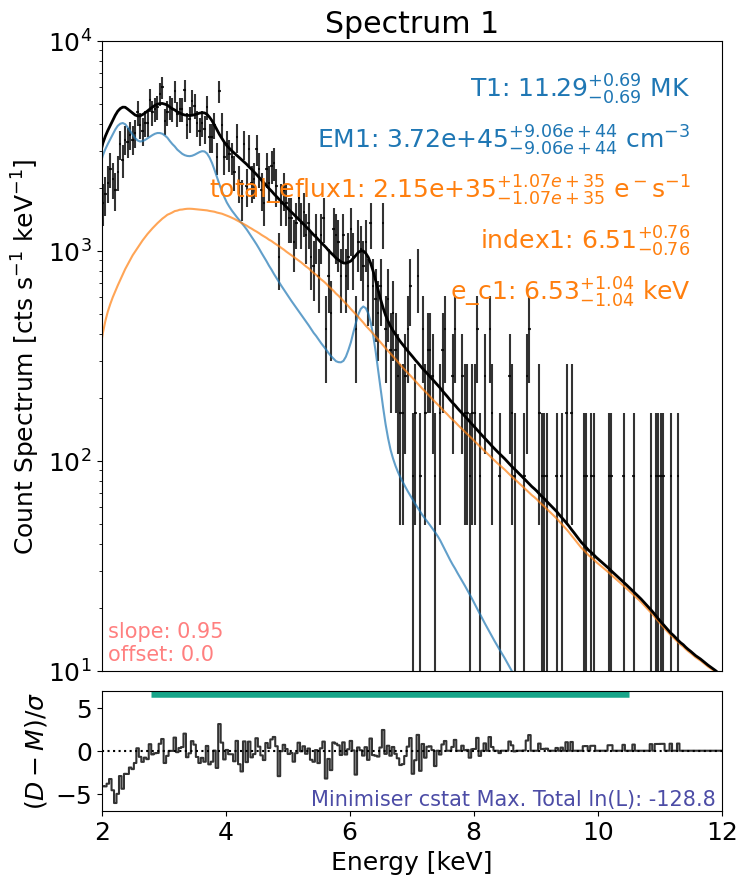

In [10]:
spec.fit(tol=1e-8)

# Plot the result
plt.rcParams["font.size"] = spec_font_size
plt.figure(figsize=spec_single_plot_size)
axes, res_axes = spec.plot()
for a in axes:
    a.set_xlim(gles_xlims)
    a.set_ylim(gles_ylims)
plt.show()
plt.rcParams["font.size"] = default_font_size

**Let's recreate something similar to Figure 3(c)**

Both NuSTAR FPMs are fitted with a thermal+cold thick target model simultaneously.

In the original Figure 3(c), a broken power law is used as the cold thick target does not exist ins XPSEC.

First, load in your data files, here we load in 2 spectra



In [11]:
_dir = "data/"
spec = Fitter(
    pha_file=[_dir + "nu20312001001A06_cl_grade0_sr_grp.pha", _dir + "nu20312001001B06_cl_grade0_sr_grp.pha"],
    arf_file=[_dir + "nu20312001001A06_cl_grade0_sr.arf", _dir + "nu20312001001B06_cl_grade0_sr.arf"],
    rmf_file=[_dir + "nu20312001001A06_cl_grade0_sr.rmf", _dir + "nu20312001001B06_cl_grade0_sr.rmf"],
)

Define model, here we go for a single isothermal model + cold thick model



In [12]:
spec.model = "C*(f_vth + thick_fn)"

Define fitting range



In [13]:
spec.energy_fitting_range = [2.8, 10.5]

Sort temperature param from f_vth



In [14]:
spec.params["T1_spectrum1"] = {"Value": 10.3, "Bounds": (1.1, 15)}
# emission measure param from f_vth
spec.params["EM1_spectrum1"] = {"Value": 0.5, "Bounds": (1e-2, 1e1)}
# electron flux param from thick_fn
spec.params["total_eflux1_spectrum1"] = {"Value": 2.1, "Bounds": (1e-3, 10)}  # units 1e35 e^-/s
# electron index param from thick_fn
spec.params["index1_spectrum1"] = {"Value": 6.2, "Bounds": (3, 10)}
# electron low energy cut-off param from thick_fn
spec.params["e_c1_spectrum1"] = {"Value": 6.2, "Bounds": (1, 12)}  # units keV
# constant for systematic offset between FPMs, found to be about 1.1
spec.params["C_spectrum1"] = "frozen"
# constant for systematic offset between FPMs, found to be about 1.1
spec.params["C_spectrum2"] = {"Status": "fixed", "Value": 1.1}
# from Gles. 2020 which had a gain correction fixed at 0.95
spec.rParams["gain_slope_spectrum1"] = {"Status": "fixed", "Value": 0.95}
spec.rParams["gain_slope_spectrum2"] = spec.rParams["gain_slope_spectrum1"]

Fit the model to the spectrum



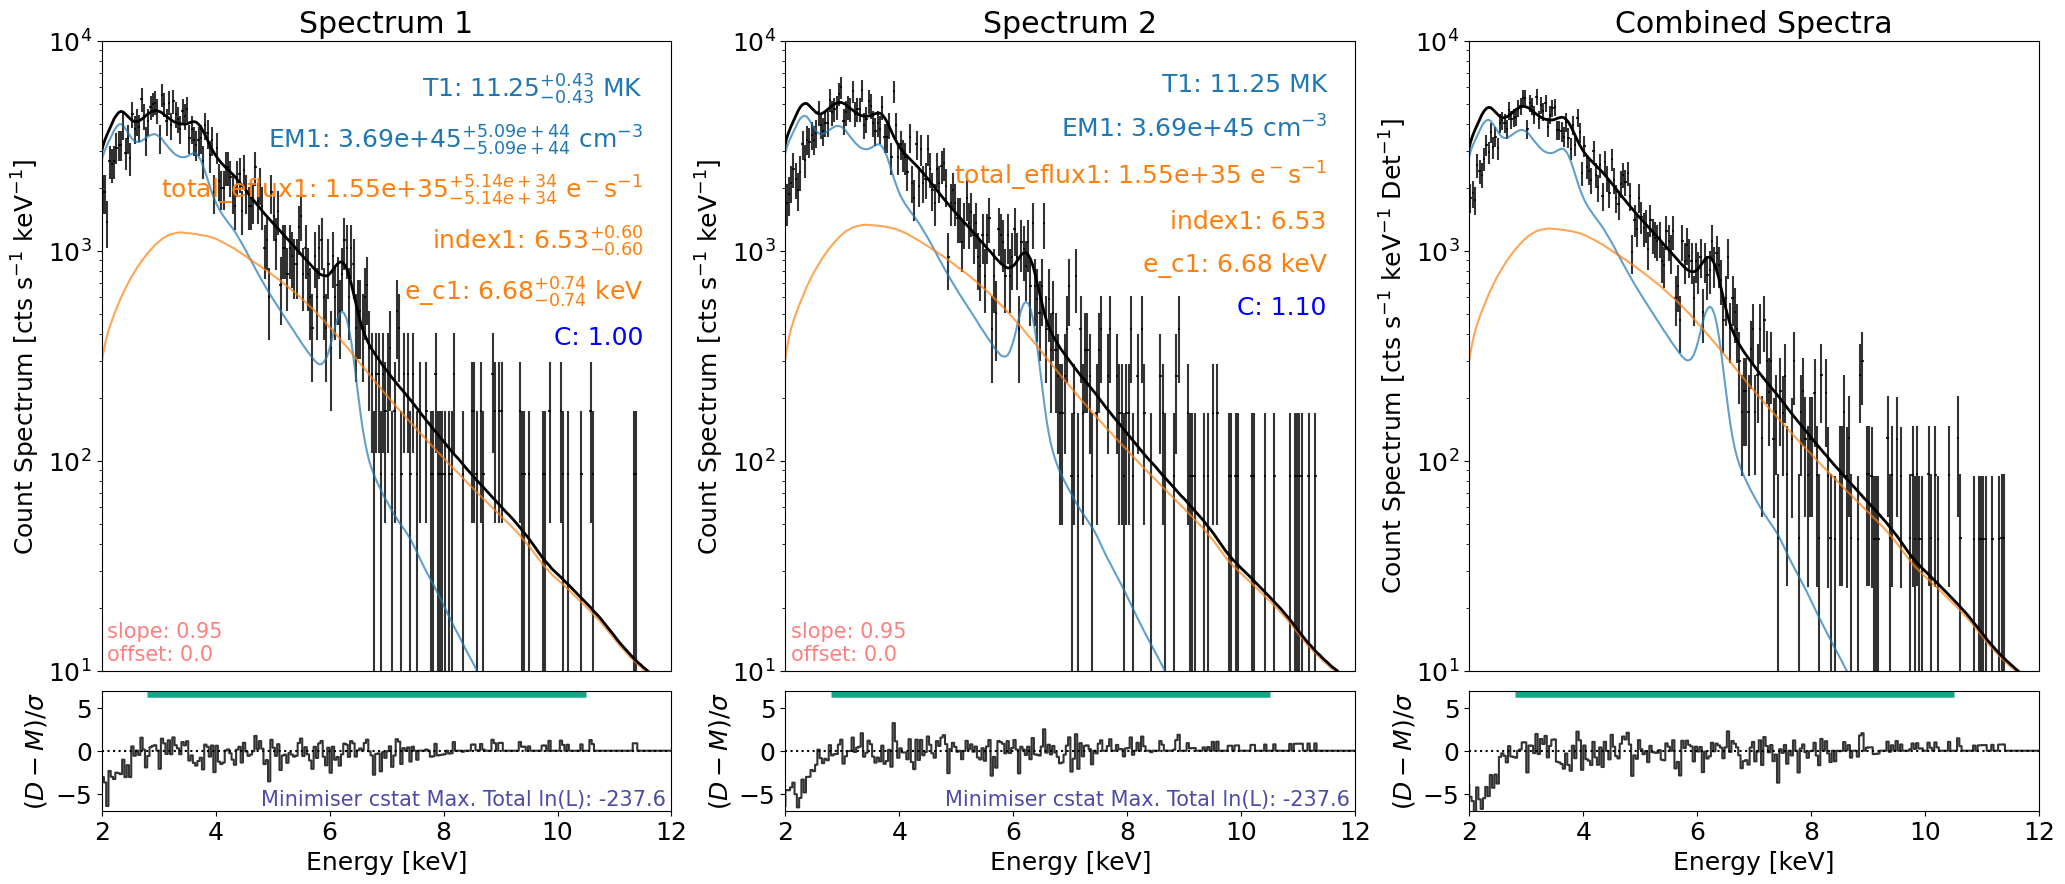

In [15]:
spec.fit(tol=1e-8)

# Plot the result
plt.rcParams["font.size"] = spec_font_size
plt.figure(figsize=spec_plot_size)
axes, res_axes = spec.plot()
for a in axes:
    a.set_xlim(gles_xlims)
    a.set_ylim(gles_ylims)
plt.show()
plt.rcParams["font.size"] = default_font_size

For the thermal and cold thick target total model we compare

| Model Parameter | OSPEX (Glesener et al. 2020) | This Work (just FPMB) | This Work (FPMA&B) |
|---|---|---|---|
| Temperature [MK] | $10.3 \pm 0.7$ | $11.3 \pm 0.7$ | $11.2 \pm 0.4$ |
| Emission Measure [$\mathrm{cm}^{-3}$] | $(5.0 \pm 1.3) \times 10^{45}$ | $(3.7 \pm 0.9) \times 10^{45}$ | $(3.7 \pm 0.5) \times 10^{45}$ |
| Electron Flux [$e^{-}\,\mathrm{s}^{-1}$] | $(2.1 \pm 1.1) \times 10^{35}$ | $(2.2 \pm 1.1) \times 10^{35}$ | $(1.6 \pm 0.5) \times 10^{35}$ |
| Index | $6.2 \pm 0.6$ | $6.5 \pm 0.8$ | $6.5 \pm 0.6$ |
| Low Energy Cut-off [keV] | $6.2 \pm 0.9$ | $6.5 \pm 1.0$ | $6.7 \pm 0.7$ |

*Glesener et al. (2020):* https://iopscience.iop.org/article/10.3847/2041-8213/ab7341

**Now let's recreate Figure 4 (right)**

NuSTAR FPMB is fitted with a warm thick target model.

The warm thick target model helps to constrain the non-thermal emission with observed values (e.g., loop length, etc) and ties it to the thermal emission parameters.

First, load in your data files, here we load in 1 spectrum



In [16]:
_dir = "data/"
spec = Fitter(
    pha_file=_dir + "nu20312001001B06_cl_grade0_sr_grp.pha",
    arf_file=_dir + "nu20312001001B06_cl_grade0_sr.arf",
    rmf_file=_dir + "nu20312001001B06_cl_grade0_sr.rmf",
)

define model, here we go for a single isothermal model + cold thick model



In [17]:
spec.model = "thick_warm"

define fitting range



In [18]:
spec.energy_fitting_range = [2.8, 10.5]

.. note:
   Note that similar parameters in the warm thick target and cold thick target models have slightly different names



In [19]:
# electron flux param
spec.params["tot_eflux1_spectrum1"] = {"Value": 2, "Bounds": (1e-2, 10)}
# electron index param
spec.params["ind1_spectrum1"] = {"Value": 6, "Bounds": (3, 10)}
# electron low energy cut-off param
spec.params["ec1_spectrum1"] = {"Value": 7, "Bounds": (3, 12)}
# loop plasma temperature param
spec.params["loop_temp1_spectrum1"] = {"Value": 10, "Bounds": (5, 15)}
# plasma number density param
spec.params["plasma_d1_spectrum1"] = {"Value": 1, "Bounds": (1e-2, 1e1)}  # units 1e10 cm^-3
# loop length param
spec.params["length1_spectrum1"] = {"Status": "fixed", "Value": 15}  # units Mm
# from Gles. 2020 which had a gain correction fixed at 0.95
spec.rParams["gain_slope_spectrum1"] = {"Status": "fixed", "Value": 0.95}

fit the model to the spectrum



Minimum length>length


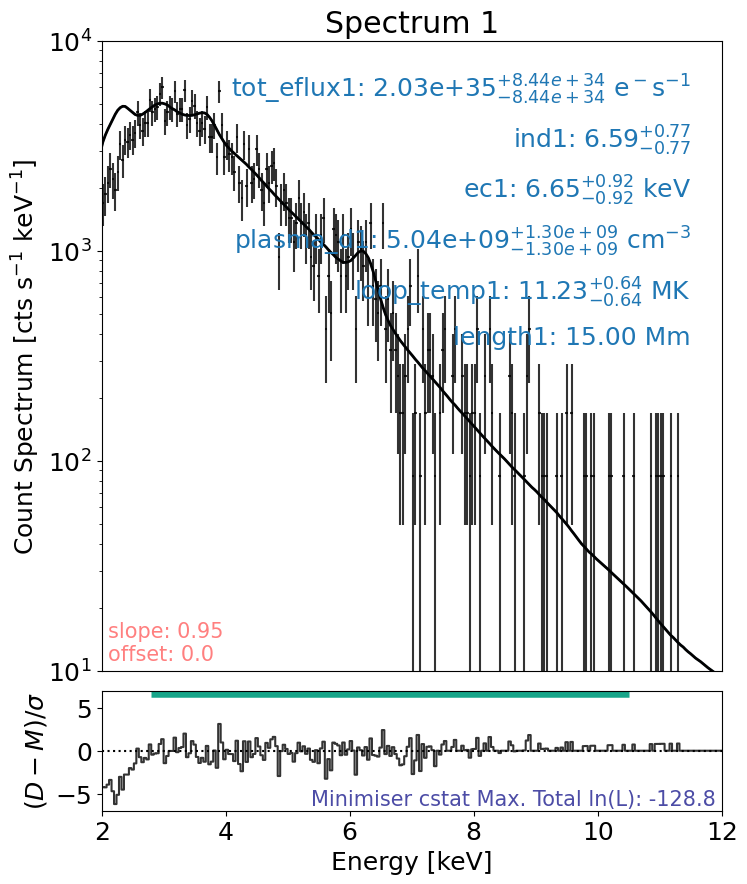

In [20]:
spec.fit(tol=1e-10)

# plot the result
plt.rcParams["font.size"] = spec_font_size
plt.figure(figsize=spec_single_plot_size)
axes, res_axes = spec.plot()
for a in axes:
    a.set_xlim(gles_xlims)
    a.set_ylim(gles_ylims)
plt.show()
plt.rcParams["font.size"] = default_font_size

**Fitting the warm thick target model to both FPMs simultaneously**


First, load in your data files, here we load in 2 spectra



In [21]:
_dir = "data/"
spec = Fitter(
    pha_file=[_dir + "nu20312001001A06_cl_grade0_sr_grp.pha", _dir + "nu20312001001B06_cl_grade0_sr_grp.pha"],
    arf_file=[_dir + "nu20312001001A06_cl_grade0_sr.arf", _dir + "nu20312001001B06_cl_grade0_sr.arf"],
    rmf_file=[_dir + "nu20312001001A06_cl_grade0_sr.rmf", _dir + "nu20312001001B06_cl_grade0_sr.rmf"],
)

Define model, here we go for a single isothermal model + cold thick model



In [22]:
spec.model = "C*thick_warm"

Define fitting range



In [23]:
spec.energy_fitting_range = [2.8, 10.5]

# electron flux param
spec.params["tot_eflux1_spectrum1"] = {"Value": 2, "Bounds": (1e-3, 10)}
# electron index param
spec.params["ind1_spectrum1"] = {"Value": 6, "Bounds": (3, 10)}
# electron low energy cut-off param
spec.params["ec1_spectrum1"] = {"Value": 7, "Bounds": (1, 12)}
# loop plasma temperature param
spec.params["loop_temp1_spectrum1"] = {"Value": 10, "Bounds": (1.1, 15)}
# plasma number density param
spec.params["plasma_d1_spectrum1"] = {"Value": 1, "Bounds": (1e-2, 1e1)}
# loop length param
spec.params["length1_spectrum1"] = {"Status": "fixed", "Value": 15}
# constant for systematic offset between FPMs, found to be about 1.1
spec.params["C_spectrum1"] = "frozen"
spec.params["C_spectrum2"] = {"Status": "fixed", "Value": 1.1}
# from Gles. 2020 which had a gain correction fixed at 0.95
spec.rParams["gain_slope_spectrum1"] = {"Status": "fixed", "Value": 0.95}
spec.rParams["gain_slope_spectrum2"] = spec.rParams["gain_slope_spectrum1"]

Fit the model to the spectrum



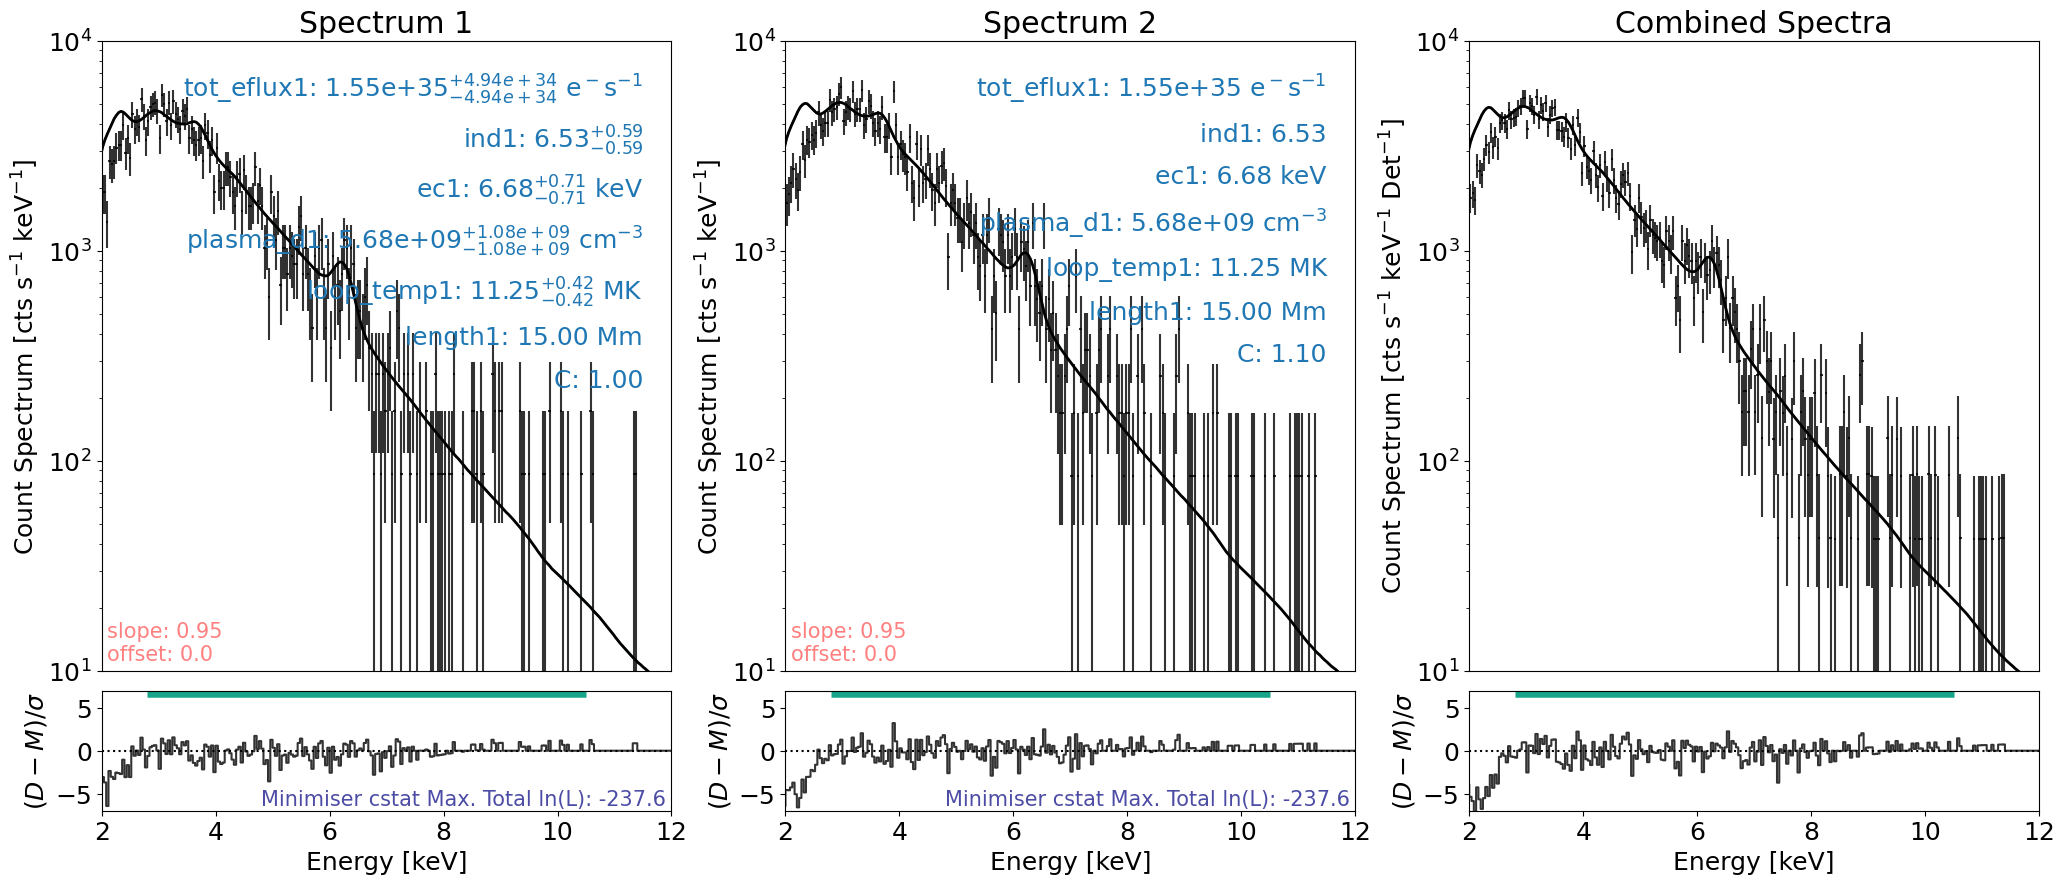

In [24]:
spec.fit(tol=1e-5)

# Plot the result
plt.rcParams["font.size"] = spec_font_size
plt.figure(figsize=spec_plot_size)
axes, res_axes = spec.plot()
for a in axes:
    a.set_xlim(gles_xlims)
    a.set_ylim(gles_ylims)
plt.show()
plt.rcParams["font.size"] = default_font_size

For warm thick target total model we compare

| Model Parameter | OSPEX (Glesener et al. 2020) | This Work (just FPMB) | This Work (FPMA&B) |
|---|---|---|---|
| Temperature [MK] | $10.2 \pm 0.7$ | $11.2 \pm 0.6$ | $11.2 \pm 0.4$ |
| Plasma Density [$\mathrm{cm}^{-3}$] | $(6.0 \pm 2.0) \times 10^{9}$ | $(5.0 \pm 1.3) \times 10^{9}$ | $(5.7 \pm 1.1) \times 10^{9}$ |
| Electron Flux [$e^{-}\,\mathrm{s}^{-1}$] | $(1.8 \pm 0.8) \times 10^{35}$ | $(2.0 \pm 0.8) \times 10^{35}$ | $(1.6 \pm 0.5) \times 10^{35}$ |
| Index | $6.3 \pm 0.7$ | $6.6 \pm 0.8$ | $6.5 \pm 0.6$ |
| Low Energy Cut-off [keV] | $6.5 \pm 0.9$ | $6.7 \pm 0.9$ | $6.7 \pm 0.7$ |

All parameter values appear to be within error margins (or extremely close). This is more impressive when the errors calculated in this work for the minimised values assumes the parameter's have a Gaussian and independent posterior distribution (which is clearly not the case) and so these errors are likely to be larger; to be investigated with an MCMC.

The simultaneous fit of FPMA&B with the cold thick target model and the warm thick model is not able to be performed in OSPEX.

